# Module 1 — Hotel Information Profile Builder

**Goal**: For each hotel, determine what is *known*, what is *missing*, and what is *outdated*.

Pipeline:
1. Load ~6,000 real Expedia reviews + 13 hotel official descriptions
2. Extract dimension mentions per review via keyword matching (20 dimensions, 4 categories)
3. Enrich policy dimensions from official `Description_PROC.csv` data
4. Output per-hotel completeness scores + prioritized gap lists

In [6]:
# Run this cell first if any packages are missing, then restart the kernel
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pandas", "matplotlib", "python-dotenv", "-q"])


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.9/bin/python3.9 -m pip install --upgrade pip


CompletedProcess(args=['/Library/Frameworks/Python.framework/Versions/3.9/bin/python3.9', '-m', 'pip', 'install', 'pandas', 'matplotlib', 'python-dotenv', '-q'], returncode=0)

In [7]:
import json, sys
from pathlib import Path
import pandas as pd

# Make module1 importable from the notebook
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

# Load the pre-generated hotel profiles
PROFILES_PATH = ROOT / "output" / "hotel_profiles.json"
with open(PROFILES_PATH) as f:
    profiles = json.load(f)

print(f"Loaded {len(profiles)} hotels")
print(f"Each hotel covers {len(next(iter(profiles.values()))['profile'])} dimensions")

Loaded 13 hotels
Each hotel covers 20 dimensions


## 1. Completeness Overview — All Hotels

In [8]:
rows = []
for pid, data in profiles.items():
    c = data["completeness"]
    gaps = data["gaps"]
    top = gaps[0] if gaps else {}
    rows.append({
        "Hotel ID": pid[:16] + "…",
        "Completeness": c["completeness_score"],
        "Review Dims": c["review_covered_dimensions"],
        "Total Covered": c["covered_dimensions"],
        "Total Dims": c["total_dimensions"],
        "# Gaps": len(gaps),
        "Top Gap": top.get("label", "—"),
        "Reason": top.get("reason", "—"),
    })

df_summary = pd.DataFrame(rows)
df_summary.style \
    .background_gradient(subset=["Completeness"], cmap="RdYlGn") \
    .format({"Completeness": "{:.1f}%"})

,Hotel ID,Completeness,Review Dims,Total Covered,Total Dims,# Gaps,Top Gap,Reason
0,110f01b8ae518a0e…,80.0%,13,16,20,9,Breakfast Hours,never_mentioned
1,3216b1b7885bffdb…,90.0%,15,18,20,10,Breakfast Hours,never_mentioned
2,3b984f3ba8df55b2…,75.0%,12,15,20,17,Breakfast Hours,never_mentioned
3,5f5a0cd8662f0ddf…,50.0%,2,10,20,12,Air Conditioning / Heating,never_mentioned
4,7d027ef72c02eaa1…,95.0%,19,19,20,12,Breakfast Hours,never_mentioned
5,823fb2499b4e37d9…,95.0%,17,19,20,9,Power Outlets & Charging,never_mentioned
6,9a0043fd4258a128…,75.0%,11,15,20,16,Air Conditioning / Heating,never_mentioned
7,a036cbe1d9fbf9cb…,60.0%,7,12,20,15,Air Conditioning / Heating,never_mentioned
8,db38b19b897dbece…,95.0%,19,19,20,14,Breakfast Hours,never_mentioned
9,e52d67a758ce4ad0…,85.0%,13,17,20,9,Breakfast Hours,never_mentioned


## 2. Dimension Coverage Heatmap — Single Hotel

Deep dive on Courtyard by Marriott Airport (most reviews, has official_conflict cases)

KeyError: 'mixed'

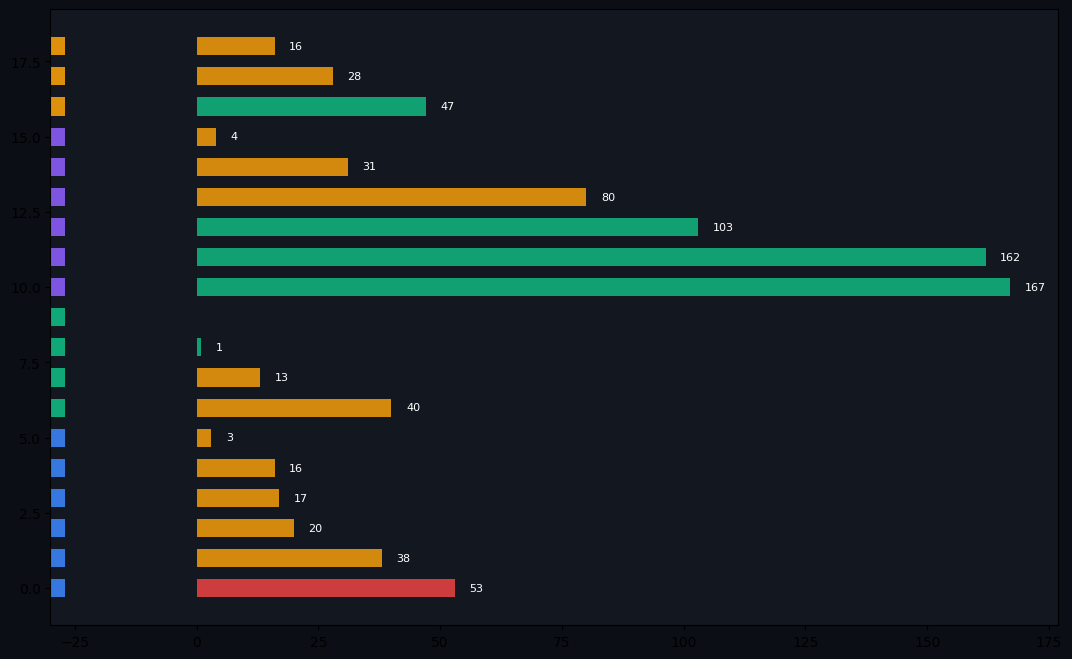

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

TARGET_PREFIX = "7d027ef7"
pid = next(p for p in profiles if p.startswith(TARGET_PREFIX))
profile = profiles[pid]["profile"]

import pandas as pd
dim_rows = []
for dim, info in profile.items():
    sentiment = info["dominant_stance"] or "unknown"
    dim_rows.append({
        "dimension": info["label"],
        "category":  info["category"],
        "mention_count": info["mention_count"],
        "sentiment": sentiment,
        "has_official": info.get("has_official_info", False),
        "conflict":  info.get("official_conflict", False),
    })

df = pd.DataFrame(dim_rows).sort_values(["category", "mention_count"], ascending=[True, False])

SENT_COLOR = {"positive": "#10B981", "negative": "#EF4444", "neutral": "#F59E0B", "unknown": "#94A3B8"}
CAT_COLOR  = {"hardware": "#3B82F6", "service": "#8B5CF6", "surroundings": "#F59E0B", "policy": "#10B981"}

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("#0B0E14")
ax.set_facecolor("#131820")

for i, (_, row) in enumerate(df.iterrows()):
    count     = row["mention_count"]
    color     = SENT_COLOR[row["sentiment"]]
    bar_width = min(count, 300)

    ax.barh(i, bar_width, color=color, alpha=0.85, height=0.6)

    if row["conflict"]:
        ax.barh(i, max(bar_width, 5), color="none", edgecolor="#FF0000", linewidth=2, height=0.6)
        ax.text(bar_width + 6, i, "! official conflict", color="#FF6B6B", va="center", fontsize=8)
    elif row["has_official"] and count == 0:
        ax.barh(i, 8, color="#3B82F6", alpha=0.4, height=0.6, hatch="///")
        ax.text(14, i, "official data known", color="#3B82F6", va="center", fontsize=8)

    if count > 0:
        ax.text(bar_width + 3, i, str(count), color="white", va="center", fontsize=8)

    ax.barh(i, 3, left=-30, color=CAT_COLOR[row["category"]], height=0.6, alpha=0.9)

ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["dimension"].tolist(), color="white", fontsize=9)
ax.set_xlabel("Number of reviews mentioning this dimension", color="#94A3B8")
ax.set_title("Courtyard by Marriott Airport — Dimension Coverage Heatmap", color="white", fontsize=13, pad=12)
ax.tick_params(colors="#94A3B8")
ax.spines[:].set_visible(False)
ax.set_xlim(-35, 360)

legend_patches = [
    mpatches.Patch(color="#10B981", label="Positive sentiment"),
    mpatches.Patch(color="#EF4444", label="Negative sentiment"),
    mpatches.Patch(color="#F59E0B", label="Neutral sentiment"),
    mpatches.Patch(color="#94A3B8", label="Unknown"),
    mpatches.Patch(color="#3B82F6", alpha=0.4, hatch="///", label="From official description"),
]
ax.legend(handles=legend_patches, loc="lower right", facecolor="#1A2230", labelcolor="white", fontsize=8)

plt.tight_layout()
plt.show()

## 3. Prioritized Gap List — Input to Module 2

This is the data Module 2 uses to decide which follow-up question to ask

In [ ]:
REASON_EMOJI = {
    "official_conflict": "🔴",
    "never_mentioned":   "🟠",
    "stale":             "🟡",
    "conflicting":       "🟢",
}

gaps = profiles[pid]["gaps"]
gap_rows = []
for g in gaps:
    gap_rows.append({
        "Priority": REASON_EMOJI.get(g["reason"], "⚪") + f" P{g['priority']}",
        "Dimension": g["label"],
        "Category": g["category"],
        "Reason": g["reason"],
        "Detail": g["reason_label"],
        "# Reviews": g["mention_count"],
        "Last Seen": g["last_mentioned"] or "—",
        "Official Info": (g.get("official_info") or "")[:60] + ("…" if len(g.get("official_info") or "") > 60 else ""),
    })

df_gaps = pd.DataFrame(gap_rows)
df_gaps.style.map(
    lambda v: "background-color: #3d0000; color: #ff8080" if "🔴" in str(v) else
              "background-color: #3d2000; color: #ffb347" if "🟠" in str(v) else
              "background-color: #3d3000; color: #ffd700" if "🟡" in str(v) else "",
    subset=["Priority"]
)

## 4. Review Evidence per Dimension

Inspect which review snippets back up each dimension's sentiment label

In [ ]:
SHOW_DIMS = ["wifi_speed", "parking", "elevator", "room_cleanliness", "staff_friendliness"]

for dim in SHOW_DIMS:
    info     = profile[dim]
    snippets = info["example_snippets"]
    sentiment = info["dominant_stance"] or "unknown"
    icon = {"positive": "✅", "negative": "❌", "neutral": "➖", "unknown": "❓"}[sentiment]

    print(f"{icon} [{info['category'].upper()}] {info['label']}  —  {info['mention_count']} reviews  —  stance: {sentiment}")

    if info.get("official_info"):
        print(f"   📋 Official: {info['official_info'][:100]}")
    if info.get("official_conflict"):
        print(f"   ⚠️  CONFLICT: official description contradicts review sentiment!")

    for s in snippets[:2]:
        print(f"   💬 \"{s[:120]}\"")
    print()

## 5. Module 1 → Module 2 Handoff Format

After a user submits a review, Module 2 receives this structure to decide what to ask

In [10]:
# Top 5 gaps passed to Module 2
module2_input = {
    "property_id": pid,
    "top_gaps": profiles[pid]["top_gaps"],
}

print("Module 2 input (JSON):\n")
print(json.dumps(module2_input, indent=2))

Module 2 input (JSON):

{
  "property_id": "7d027ef72c02eaa17af3c993fd5dba50d17b41a6280389a46c13c7e2c32a5b06",
  "top_gaps": [
    {
      "dimension": "breakfast_hours",
      "label": "Breakfast Hours",
      "category": "policy",
      "reason": "never_mentioned",
      "reason_label": "No data yet",
      "priority": 3,
      "mention_count": 0,
      "last_mentioned": null,
      "dominant_stance": null,
      "official_info": null
    },
    {
      "dimension": "checkout_time",
      "label": "Check-out Time",
      "category": "policy",
      "reason": "stale",
      "reason_label": "Last mentioned 10 months ago",
      "priority": 2,
      "mention_count": 1,
      "last_mentioned": "2025-06-16",
      "dominant_stance": "positive",
      "official_info": "Check-out by 11:00 AM; Check-out before 11:00 AM; Express check-out available"
    },
    {
      "dimension": "elevator",
      "label": "Elevator",
      "category": "hardware",
      "reason": "stale",
      "reason_label